# Hometask 16: Time Series Forecasting

1. Load the **Electricity Consumption data** in Romania (`./datasets/electricity_consumption_and_production.csv`). Use the `Consumption` column as the target variable.
2. Perform **EDA**: decompose the series, plot ACF and PACF, and run the ADF stationarity test. Note that the data contains **hourly observations** — resample to daily before performing forecast.
3. Clean data if necessary.
4. Train forecasting models (Use models from the lecture or other ones if you wish) and produce forecasts for **15, 30, and 45 days ahead**.
5. Visualize predictions and provide evaluation metrics

---
**Models covered in this HW:**
1. Naive Seasonal (baseline)
2. SARIMA(2,0,1)(1,1,1,7) — selected by Optuna
3. Holt-Winters Exponential Smoothing  
4. Prophet  
5. XGBoost  
6. Amazon Chronos


## 1. Imports

for this HW use google colab because not all models support ARM

In [33]:
!pip install -q darts prophet lightgbm optuna chronos-forecasting

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import logging
logging.getLogger("lightgbm").setLevel(logging.ERROR)

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from pathlib import Path

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

from chronos import ChronosPipeline

from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mae, rmse, mape
from darts.models import (
    NaiveSeasonal,
    ARIMA,
    ExponentialSmoothing,
    Prophet,
    XGBModel,
)
from darts.utils.utils import ModelMode, SeasonalityMode

NUM_SAMPLES = 500 # Number of samples to use from the dataset

print("All imports OK")

All imports OK


## Load and resample to daily

In [ ]:
path = Path.cwd() / "data" / "electricity_consumption_and_production.csv"

raw = pd.read_csv(
    path,
    parse_dates=["DateTime"],
    index_col="DateTime",
)

print(f"Raw hourly: {raw.shape}; {raw.index.min().date()} => {raw.index.max().date()}")

# resample, interpolate missing days
daily = raw["Consumption"].resample("D").mean().interpolate(method="time")
print(f"Daily: {daily.shape}; NaNs: {daily.isna().sum()}")
daily.describe().to_frame()

Raw hourly: (54161, 9); 2019-01-01 => 2025-03-19
Daily: (2270,); NaNs: 0


,Consumption
count,2270.000000
mean,6526.819658
std,763.696661
min,3851.083333
25%,5991.906250
50%,6542.145833
75%,7045.197917
max,8728.291667


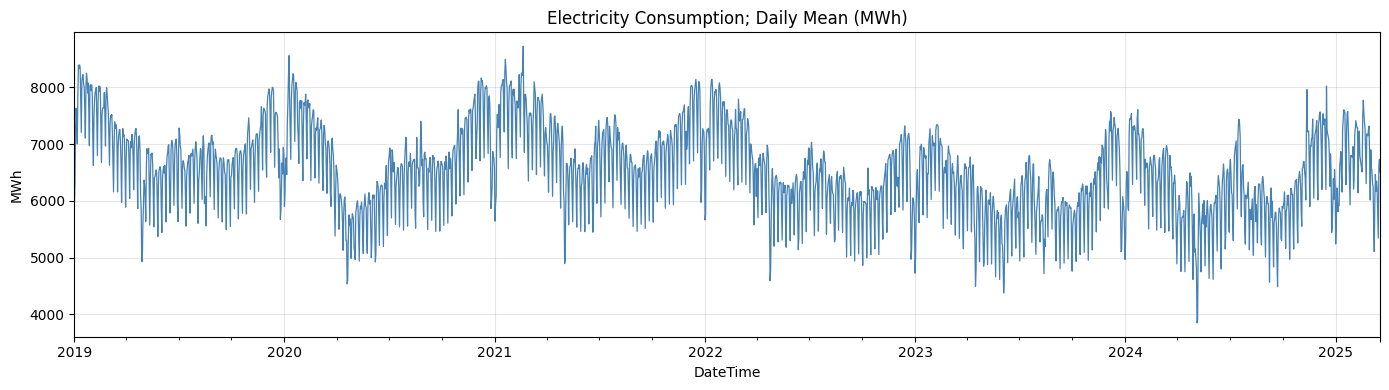

In [36]:
fig, ax = plt.subplots(figsize=(14, 4))
daily.plot(ax=ax, color="steelblue", lw=0.9)
ax.set(title="Electricity Consumption; Daily Mean (MWh)", ylabel="MWh")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## EDA

### Seasonal Decomposition

I decompose at two periods: `7` and `365` days

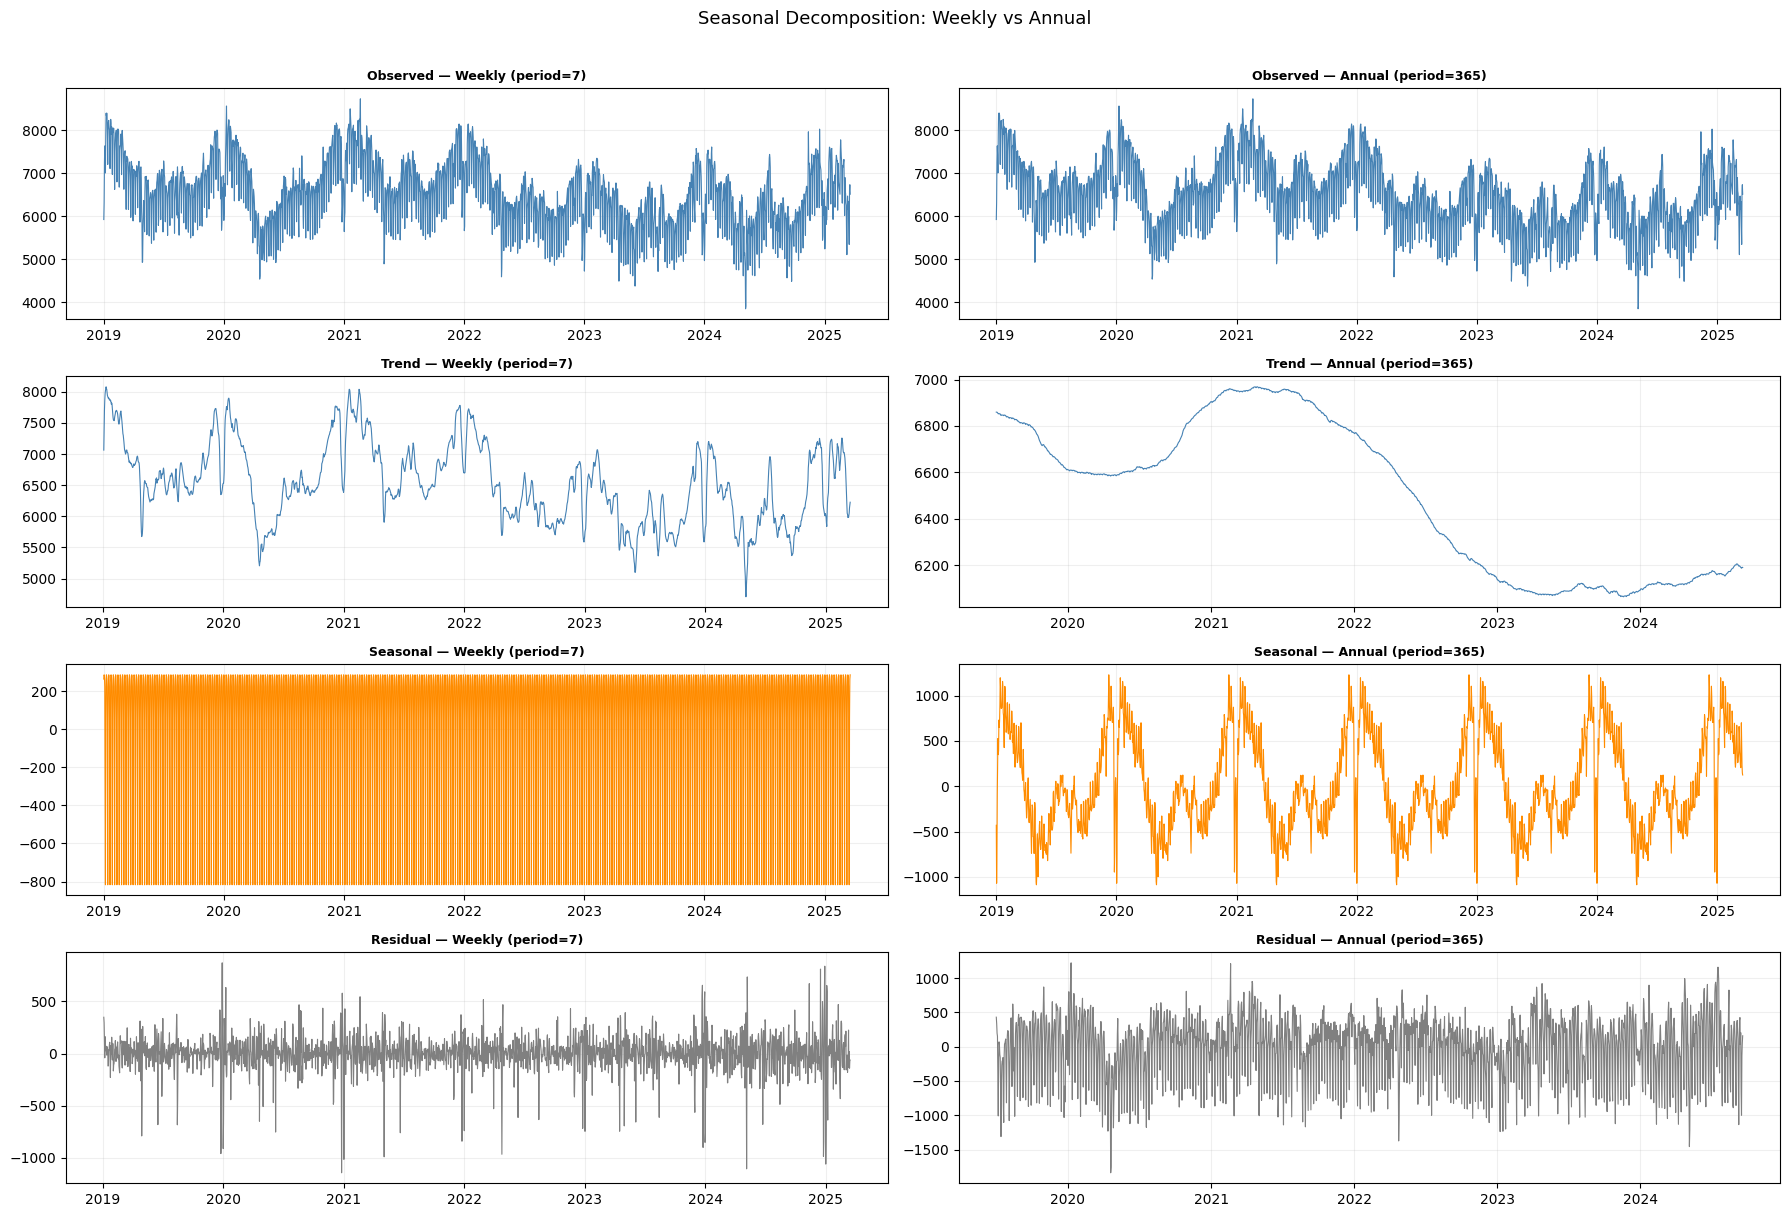

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(18, 12), sharex=False)
periods = [7, 365]
titles  = ["Weekly (period=7)", "Annual (period=365)"]

for col, (period, title) in enumerate(zip(periods, titles)):
    decomp = seasonal_decompose(daily, model="additive", period=period)
    parts  = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
    labels = ["Observed", "Trend", "Seasonal", "Residual"]
    colors = ["steelblue", "steelblue", "darkorange", "gray"]

    for row, (s, lbl, col_c) in enumerate(zip(parts, labels, colors)):
        axes[row][col].plot(s, color=col_c, lw=0.8)
        axes[row][col].set_title(f"{lbl} — {title}", fontsize=9, fontweight="bold")
        axes[row][col].grid(True, alpha=0.2)

plt.suptitle("Seasonal Decomposition: Weekly vs Annual", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### ACF and PACF

- **ACF**: slow decay + spikes at lags 7, 14 … → strong **weekly seasonality**
- **PACF**: sharp cutoff after lag 2 → AR(1-2) sufficient for the non-seasonal part

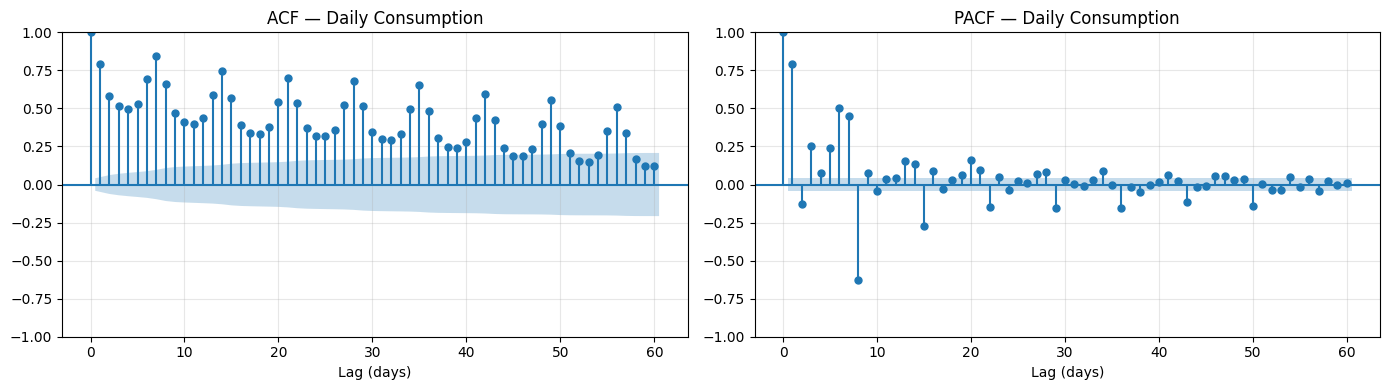

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf( daily, lags=60, ax=axes[0], title="ACF — Daily Consumption")
plot_pacf(daily, lags=60, method="ywm", ax=axes[1], title="PACF — Daily Consumption")
for ax in axes:
    ax.set_xlabel("Lag (days)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Stationarity — ADF Test

In [39]:
def adf_test(series: pd.Series, label: str) -> dict:
    r = adfuller(series.dropna())
    return {
        "Series": label,
        "ADF Statistic": round(r[0], 4),
        "p-value": round(r[1], 4),
        "Lags used": r[2],
        "Obs": r[3],
        "Stationary": "Yes" if r[1] < 0.05 else "No",
    }

adf_orig = adf_test(daily, "Original")
adf_diff = adf_test(daily.diff().dropna(), "Differenced")

pd.DataFrame([adf_orig, adf_diff]).set_index("Series")

,ADF Statistic,p-value,Lags used,Obs,Stationary
Series,,,,,
Original,-3.3884,0.0114,27,2242,Yes
Differenced,-11.3973,0.0000,27,2241,Yes


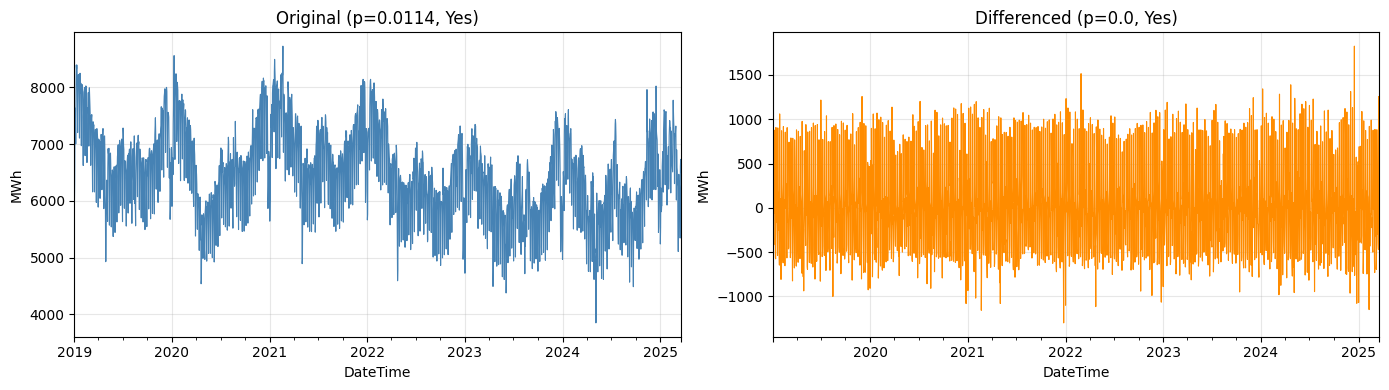

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
daily.plot(ax=axes[0], color="steelblue", lw=0.8,
    title=f"Original (p={adf_orig['p-value']}, {adf_orig['Stationary']})")
daily.diff().dropna().plot(ax=axes[1], color="darkorange", lw=0.8,
    title=f"Differenced (p={adf_diff['p-value']}, {adf_diff['Stationary']})")
for ax in axes:
    ax.set_ylabel("MWh")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Clean Data

Missing days from the resample step are already filled with `.interpolate(method="time")`  
Just ensure the full daily range has no remaining gaps

In [ ]:
clean = (
    daily
    .reindex(pd.date_range(daily.index.min(), daily.index.max(),
                           freq="D"))
    .interpolate(method="time")
)
print(f"Clean: {clean.shape}; NaNs: {clean.isna().sum()}")
clean.describe().to_frame()

Clean: (2270,); NaNs: 0


,Consumption
count,2270.000000
mean,6526.819658
std,763.696661
min,3851.083333
25%,5991.906250
50%,6542.145833
75%,7045.197917
max,8728.291667


## Feature Engineering; Calendar Covariates

Electricity consumption depends heavily on **day of week** and **month**.  
Encode this for XGBoost(or LightGBM)

In [42]:
cov_df = pd.DataFrame({
    "day_of_week": clean.index.dayofweek.astype(float), # mon=0, tue=1, … sun=6
    "month": clean.index.month.astype(float),
    "is_weekend": (clean.index.dayofweek >= 5).astype(float),
}, index=clean.index)

cov_df.head(7)

,day_of_week,month,is_weekend
2019-01-01,1.0,1.0,0.0
2019-01-02,2.0,1.0,0.0
2019-01-03,3.0,1.0,0.0
2019-01-04,4.0,1.0,0.0
2019-01-05,5.0,1.0,1.0
2019-01-06,6.0,1.0,1.0
2019-01-07,0.0,1.0,0.0


## Train/Test Split

Test set is last **45 days**.

In [43]:
HORIZONS  = [15, 30, 45]
TEST_DAYS = 45

ts_full = TimeSeries.from_series(clean, freq="D") # ts_full covers the entire range (train + test) and is used for plotting and metrics
ts_cov_full = TimeSeries.from_dataframe(cov_df)

ts_train = ts_full[:-TEST_DAYS] # ts_train covers only the training range and is used for fitting the models
ts_test = ts_full[-TEST_DAYS:] # ts_test covers only the test range and is used for evaluation
ts_cov_train = ts_cov_full[:-TEST_DAYS] # ts_cov_train covers only the training range and is used for fitting the models

# Scaler fitted on train only, transform full series for models
scaler = Scaler()
ts_train_scaled = scaler.fit_transform(ts_train)


## Metrics Helpers

idea from lecture and some refacroring with modern tools

In [ ]:
all_metrics   = {}
all_forecasts = {}
results       = []
CONTEXT = 90 # days of train context shown on the plots

MODEL_COLORS = {
    "Naive Seasonal": "gray",
    "SARIMA": "tomato",
    "Exp. Smoothing": "darkorange",
    "Prophet": "purple",
    "XGBoost": "royalblue",
    "LightGBM" : "royalblue",
    "Chronos (zero-shot)": "teal",
}
MODEL_LIST = list(MODEL_COLORS.keys())

def score_and_store(model_name: str, pred_ts: TimeSeries) -> None:
    """Stores metrics and forecast. For probabilistic — uses median."""
    is_prob = pred_ts.n_samples > 1
    pred_point = pred_ts.quantile(0.5) if is_prob else pred_ts
    metrics = {}
    for h in HORIZONS:
        m = {
            "MAE": round(mae(ts_test[:h], pred_point[:h]),  2),
            "RMSE": round(rmse(ts_test[:h], pred_point[:h]), 2),
            "MAPE (%)": round(mape(ts_test[:h], pred_point[:h]), 2),
        }
        metrics[f"{h}d"] = m
        results.append({"Model": model_name, "Horizon": h, **m})
    all_metrics[model_name]   = metrics
    all_forecasts[model_name] = pred_ts
    mape_str = " | ".join(
        f"{h}d MAPE={metrics[f'{h}d']['MAPE (%)']:.1f}%" for h in HORIZONS
    )
    print(f"{model_name:<30} {mape_str}")


def plot_forecast(model_name: str) -> None:
    """ Visualize forecast for 15 / 30 / 45 days (lecture style).
    Train | Actual | Forecast (median) + 80% CI for probabilistic models.
    """
    pred = all_forecasts[model_name]
    color = MODEL_COLORS[model_name]
    is_prob = pred.n_samples > 1
    median = pred.quantile(0.5) if is_prob else pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
    fig.suptitle(model_name, fontsize=13, fontweight="bold", y=1.01)

    for ax, h in zip(axes, HORIZONS):
        ts_train[-CONTEXT:].to_series().plot(
            ax=ax, color="steelblue", lw=1.8, label="Training data")
        ts_test[:h].to_series().plot(
            ax=ax, color="green",    lw=1.8, label="Actual values")
        median[:h].to_series().plot(
            ax=ax, color=color,      lw=1.8, label="Forecast (median)")

        if is_prob:
            low  = pred[:h].quantile(0.1).values()[:, 0]
            high = pred[:h].quantile(0.9).values()[:, 0]
            ax.fill_between(
                pred.time_index[:h], low, high,
                alpha=0.25, color=color, label="80% CI"
            )

        m = all_metrics[model_name][f"{h}d"]
        summary = f"MAPE {m['MAPE (%)']:.1f}%  |  MAE {m['MAE']:.1f}"
        ax.text(0.99, 0.97, summary, transform=ax.transAxes, fontsize=9,
                ha="right", va="top",
                bbox=dict(facecolor="white", alpha=0.8,
                          edgecolor="gray", boxstyle="round,pad=0.4"))

        ax.set_title(f"{model_name} — {h}-Day Forecast",
                     fontsize=10, fontweight="bold")
        ax.set_ylabel("MWh")
        ax.legend(loc="upper left", fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


## Forecasting Models

### Naive Seasonal Baseline

Repeats the last observed **weekly cycle**.
The floor that model must beat

In [45]:
naive = NaiveSeasonal(K=7) # weekly seasonality
naive.fit(ts_train)
naive_pred = naive.predict(TEST_DAYS)
score_and_store("Naive Seasonal", naive_pred)

  Naive Seasonal                 15d MAPE=5.6% | 30d MAPE=5.8% | 45d MAPE=7.0%


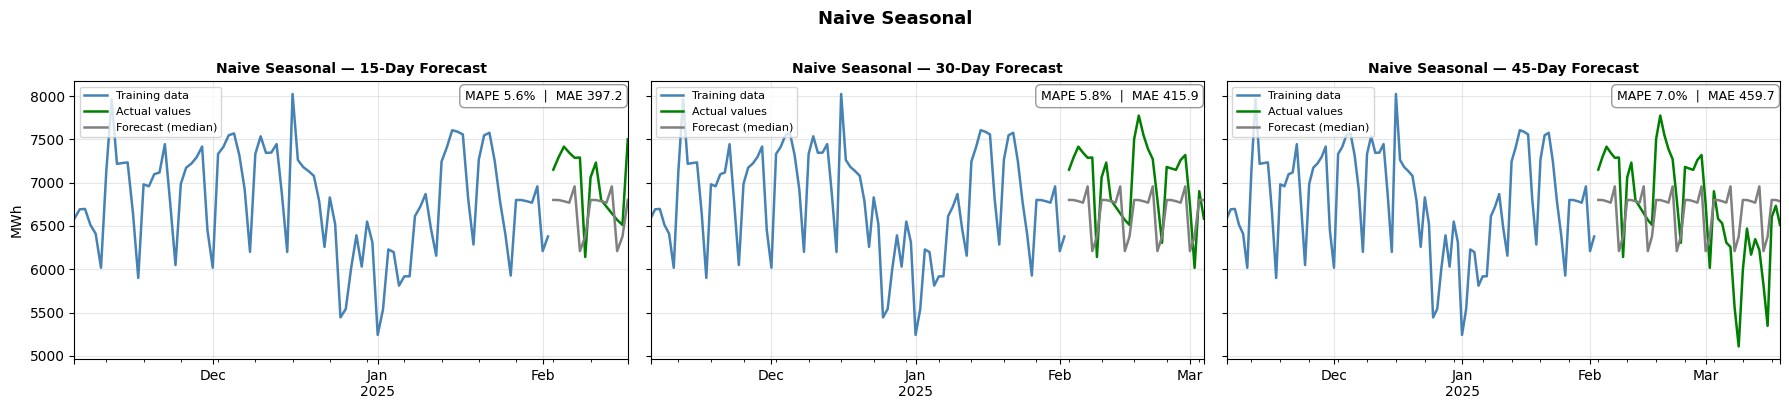

In [46]:
plot_forecast("Naive Seasonal")

### SARIMA with Optuna hyperparam

The seasonal order `(P,D,Q,7)` captures the weekly cycle.
`d=1` removes the trend; `D=1` removes seasonal non-stationarity.
Optimal `p,d,q,P,D,Q` are selected via Bayesian optimization (Optuna, 30 trials)

In [47]:
def sarima_objective(trial):
    p = trial.suggest_int("p", 0, 3)
    d = trial.suggest_int("d", 0, 1)
    q = trial.suggest_int("q", 0, 3)
    P = trial.suggest_int("P", 0, 2)
    D = trial.suggest_int("D", 0, 1)
    Q = trial.suggest_int("Q", 0, 2)
    try:
        model = ARIMA(p=p, d=d, q=q, seasonal_order=(P, D, Q, 7))
        model.fit(ts_train)
        pred = model.predict(n=TEST_DAYS)
        return mape(ts_test, pred)
    except Exception:
        return float("inf")

study_sarima = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
print("Tuning SARIMA (30 trials) ...")
study_sarima.optimize(sarima_objective, n_trials=30, show_progress_bar=True)

bp = study_sarima.best_params
print(f"\nBest MAPE: {study_sarima.best_value:.2f}%")
print(f"Best params: {bp}")

sarima = ARIMA(
    p=bp["p"], d=bp["d"], q=bp["q"],
    seasonal_order=(bp["P"], bp["D"], bp["Q"], 7)
)
sarima.fit(ts_train)
sarima_pred = sarima.predict(n=TEST_DAYS, num_samples=NUM_SAMPLES)
score_and_store("SARIMA", sarima_pred)


Tuning SARIMA (30 trials) ...


  0%|          | 0/30 [00:00<?, ?it/s]


Best MAPE: 5.38%
Best params: {'p': 2, 'd': 0, 'q': 1, 'P': 1, 'D': 1, 'Q': 1}
  SARIMA                         15d MAPE=3.5% | 30d MAPE=4.5% | 45d MAPE=5.2%


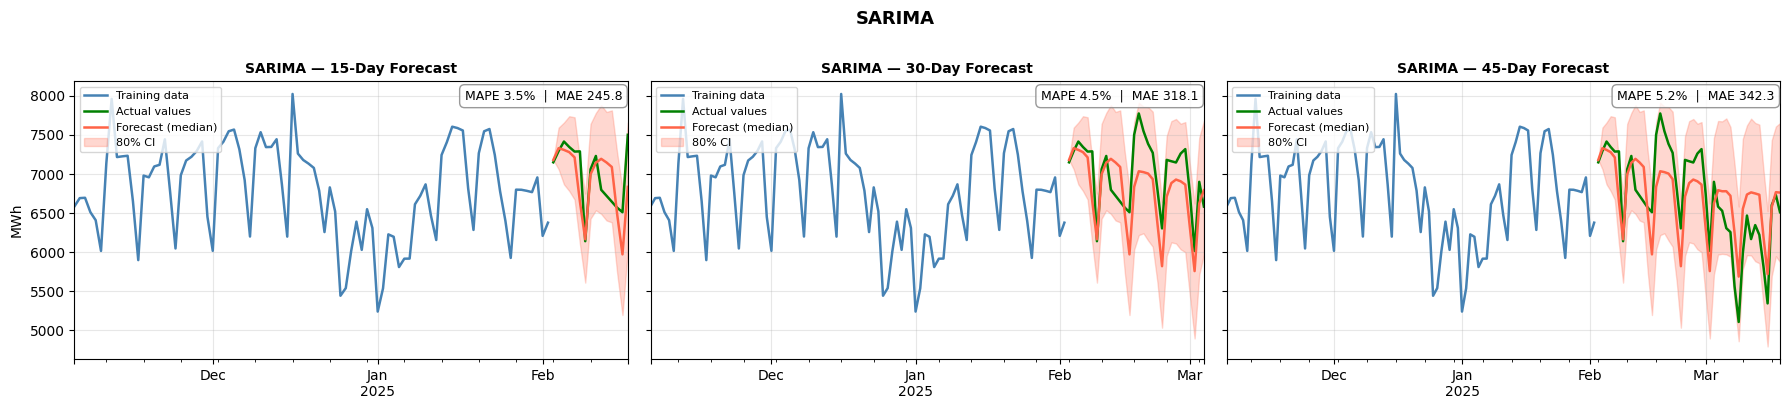

In [48]:
plot_forecast("SARIMA")


### Exponential Smoothing

Triple exponential smoothing: level, trend, seasonality.
Optuna-tuned (based on SARIMA tuning).
Best for daily electricity data: additive trend + additive seasonal, damped=True, seasonal_periods=7.

In [49]:
# Parameters chosen via Optuna, hardcoded here for reproducibility.
# for daily data: additive trend, additive seasonal, damped
es = ExponentialSmoothing(
    trend=ModelMode.ADDITIVE,
    seasonal=SeasonalityMode.ADDITIVE,
    damped=True,
    seasonal_periods=7,
)

es.fit(ts_train)
es_pred = es.predict(n=TEST_DAYS, num_samples=NUM_SAMPLES)
score_and_store("Exp. Smoothing", es_pred)


  Exp. Smoothing                 15d MAPE=4.2% | 30d MAPE=3.4% | 45d MAPE=8.0%


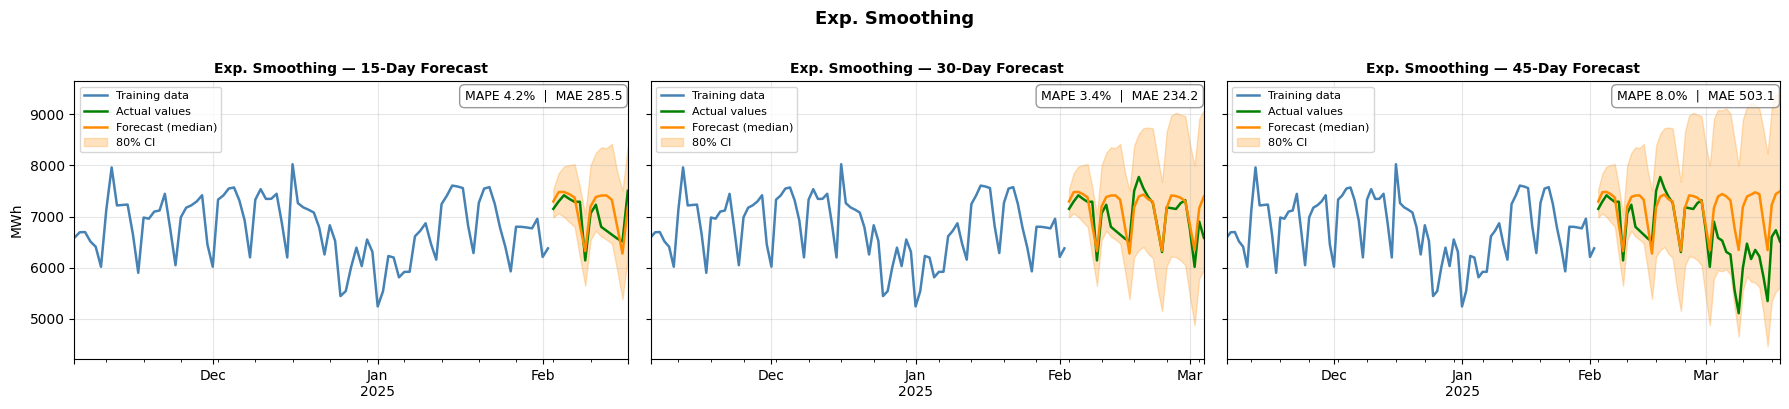

In [50]:
plot_forecast("Exp. Smoothing")


### Prophet

Hyperparam chosen via Optuna: `changepoint_prior_scale=0.127`, `seasonality_prior_scale=2.654`.


In [51]:
prophet = Prophet(
    changepoint_prior_scale=0.1269925849310998,
    seasonality_prior_scale=2.6542737768328535,
)

prophet.fit(ts_train)
prophet_pred = prophet.predict(n=TEST_DAYS, num_samples=NUM_SAMPLES)
score_and_store("Prophet", prophet_pred)


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


  Prophet                        15d MAPE=4.8% | 30d MAPE=4.5% | 45d MAPE=5.4%


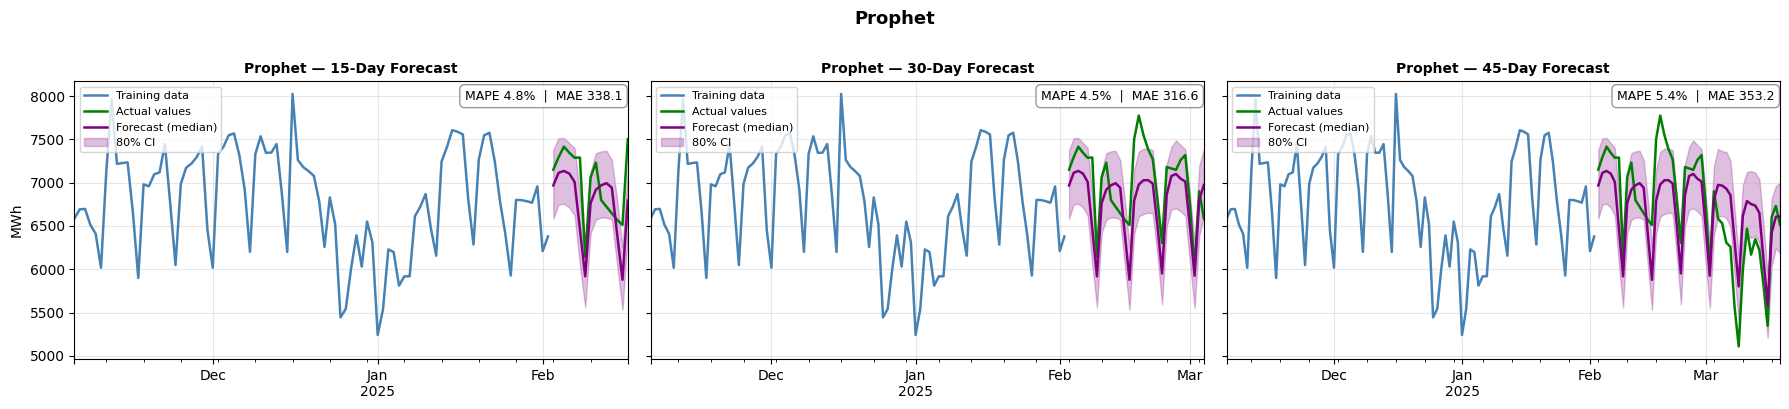

In [52]:
plot_forecast("Prophet")


### XGBoost

XGBoost builds an ensemble of decision trees on lag features, past values of the series.
`lags=30` means the model sees the last 30 days as input features to predict the next day.
Unlike the lecture (where XGBoost was trained globally on 4 products simultaneously),
here there is only one series — so global training is not applied, but the approach is identical.


In [53]:
print("Fitting XGBoost ...")
xgb = XGBModel(
    lags=30,
    output_chunk_length=TEST_DAYS,
    random_state=42,
)
xgb.fit(ts_train_scaled)
xgb_pred_scaled = xgb.predict(n=TEST_DAYS)
xgb_pred = scaler.inverse_transform(xgb_pred_scaled)
score_and_store("XGBoost", xgb_pred)


Fitting XGBoost ...
  XGBoost                        15d MAPE=5.5% | 30d MAPE=5.0% | 45d MAPE=7.6%


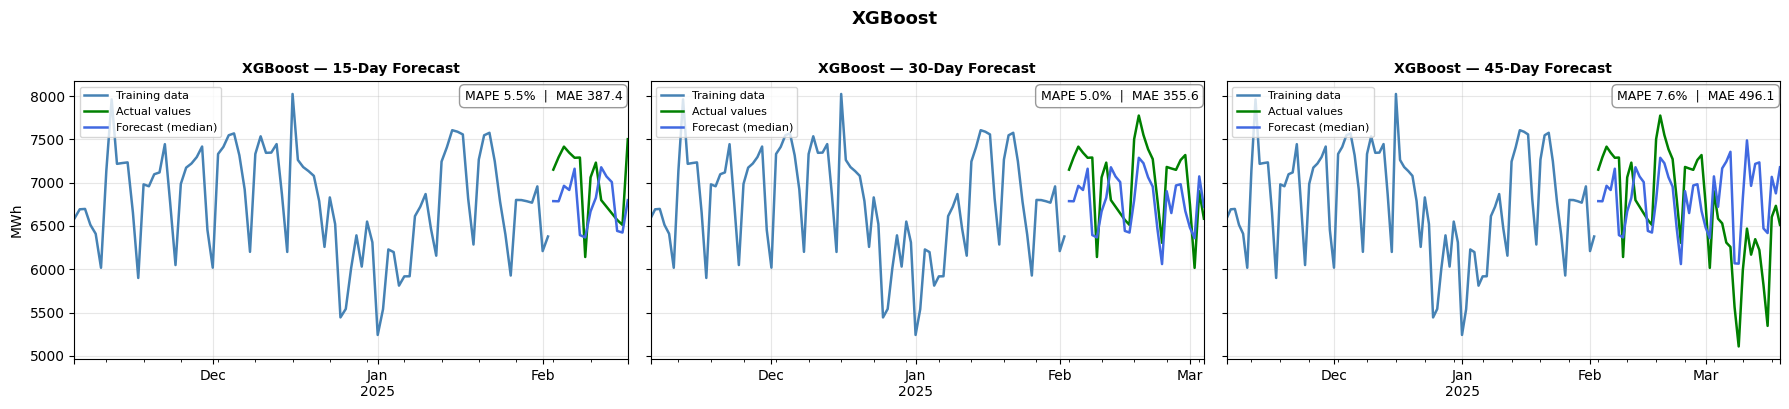

In [54]:
plot_forecast("XGBoost")


### LightGBM
A fast boosting-based alternative to XGBoost for lag features


In [55]:
from darts.models import LightGBMModel
lgbm = LightGBMModel(
    lags=30,
    output_chunk_length=TEST_DAYS,
    random_state=42,
    verbose=-1,
)
lgbm.fit(ts_train_scaled)
lgbm_pred_scaled = lgbm.predict(n=TEST_DAYS)
lgbm_pred = scaler.inverse_transform(lgbm_pred_scaled)
score_and_store("LightGBM", lgbm_pred)

  LightGBM                       15d MAPE=5.7% | 30d MAPE=5.1% | 45d MAPE=7.3%


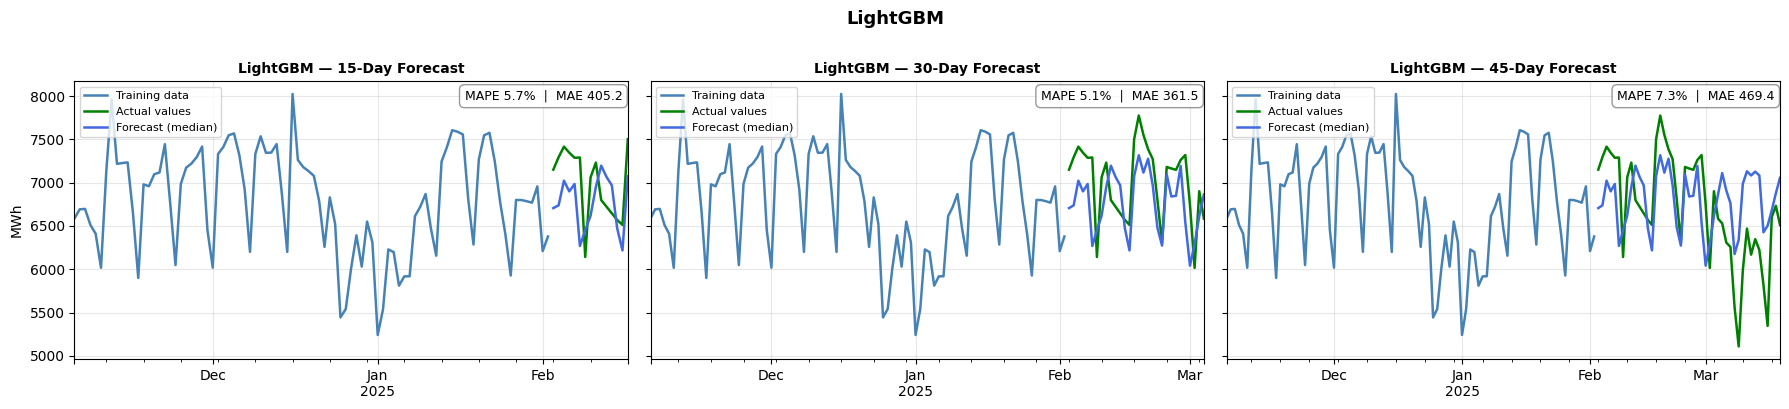

In [56]:
plot_forecast("LightGBM")

### Amazon Chronos (Zero-Shot)

Foundation model pre-trained on millions of time series — **no fine-tuning needed**.  
Use `chronos-t5-tiny`, model sees only the context — no target labels.

In [58]:
chronos_pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",
    device_map="cuda",
    torch_dtype=torch.float32,
)

context = torch.tensor(ts_train.to_series().values, dtype=torch.float32)

prediction = chronos_pipeline.predict(
    context,
    prediction_length=TEST_DAYS,
    num_samples=NUM_SAMPLES,
)

chronos_values = prediction[0].numpy()
chronos_prob   = chronos_values.T[:, np.newaxis, :]
chronos_pred   = TimeSeries.from_times_and_values(ts_test.time_index, chronos_prob)

score_and_store("Chronos (zero-shot)", chronos_pred)

  Chronos (zero-shot)            15d MAPE=6.5% | 30d MAPE=7.4% | 45d MAPE=6.6%


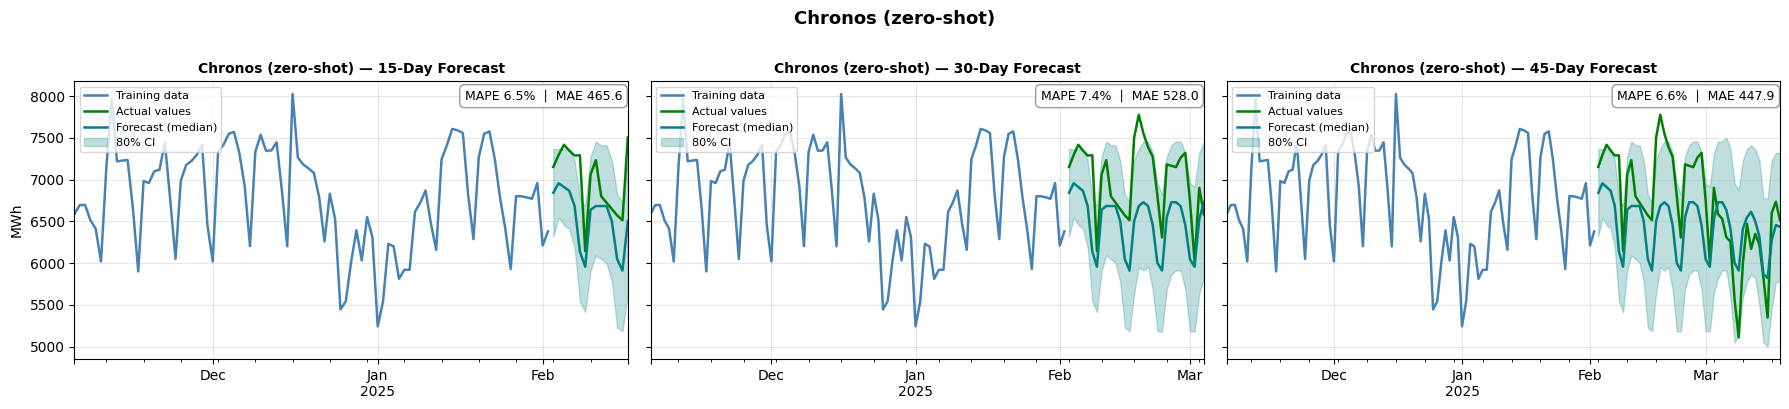

In [59]:
plot_forecast("Chronos (zero-shot)")


## Evaluation Metrics

### Heatmap with MAE, RMSE, MAPE

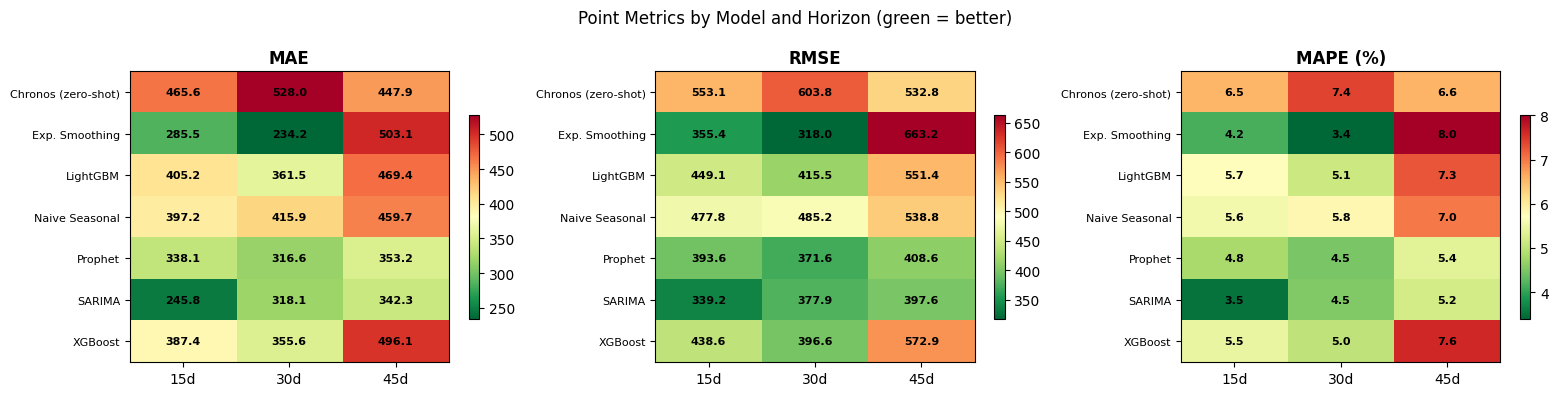

In [67]:
rows = [
    {"Model": name, "Horizon": h_key, **m} # unpack metrics for DataFrame
    for name, horizons in all_metrics.items()
    for h_key, m in horizons.items()
]
metrics_df = pd.DataFrame(rows).set_index(["Model", "Horizon"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["MAE", "RMSE", "MAPE (%)"]):
    pivot = metrics_df[metric].unstack("Horizon")[["15d", "30d", "45d"]]
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(3))
    ax.set_xticklabels(["15d", "30d", "45d"])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    ax.set_title(metric, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.7)
    for ii in range(len(pivot.index)):
        for jj in range(3):
            ax.text(jj, ii, f"{pivot.values[ii,jj]:.1f}",
                    ha="center", va="center", fontsize=8, fontweight="bold")
plt.suptitle("Point Metrics by Model and Horizon (green = better)", fontsize=12)
plt.tight_layout()
plt.show()


### 10b. MAPE Line Chart — How Models Scale with Horizon

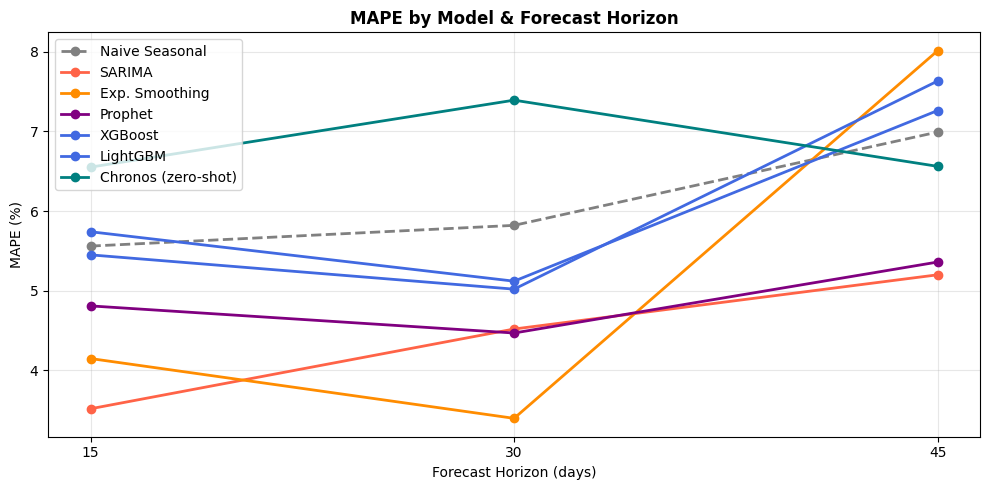

In [61]:
results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset=["Model", "Horizon"], keep="last")
)

fig, ax = plt.subplots(figsize=(10, 5))
for name in MODEL_LIST:
    d = results_df[results_df["Model"] == name].sort_values("Horizon")
    ls = "--" if name == "Naive Seasonal" else "-"
    ax.plot(d["Horizon"], d["MAPE (%)"],
            marker="o", lw=2, ls=ls, label=name, color=MODEL_COLORS[name])

ax.set_xlabel("Forecast Horizon (days)")
ax.set_ylabel("MAPE (%)")
ax.set_xticks(HORIZONS)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_title("MAPE by Model & Forecast Horizon", fontweight="bold")
plt.tight_layout()
plt.show()

### MAPE Table

In [62]:
pivot_mape = (
    results_df
    .pivot_table(index="Model", columns="Horizon", values="MAPE (%)")
    .rename(columns={15: "MAPE 15d", 30: "MAPE 30d", 45: "MAPE 45d"})
    .reindex(MODEL_LIST)
)

pivot_mape.style \
    .background_gradient(cmap="RdYlGn_r", axis=None) \
    .format("{:.2f}") \
    .set_caption("MAPE by Model and Horizon; (green = better)")


Horizon,MAPE 15d,MAPE 30d,MAPE 45d
Model,,,
Naive Seasonal,5.56,5.82,6.99
SARIMA,3.52,4.52,5.20
Exp. Smoothing,4.15,3.40,8.01
Prophet,4.81,4.47,5.36
XGBoost,5.45,5.02,7.63
LightGBM,5.74,5.12,7.26
Chronos (zero-shot),6.55,7.39,6.56


### Best Model per Horizon

In [63]:
best = (
    results_df
    .loc[results_df.groupby("Horizon")["MAPE (%)"].idxmin()]
    [["Horizon", "Model", "MAPE (%)", "MAE", "RMSE"]]
    .sort_values("Horizon")
    .reset_index(drop=True)
)
best

,Horizon,Model,MAPE (%),MAE,RMSE
0,15,SARIMA,3.52,245.77,339.16
1,30,Exp. Smoothing,3.40,234.18,317.97
2,45,SARIMA,5.20,342.34,397.59


### Conclusions

- **SARIMA** showed the best results for the **15** and **45**-day forecasts. This is expected because the dataset has clear weekly seasonality, which SARIMA handles well.
- **Exp. Smoothing** gave the best result for the **30**-day forecast, but its accuracy became much worse at **45** days, so it is less reliable for longer forecasts.
- **Prophet** produced stable results on all forecast horizons, but it was not the best model.
- **Naive Seasonal** is a useful baseline model: SARIMA, Exp. Smoothing, Prophet, and XGBoost performed better on the **15** and **30**-day forecasts, but on the **45** day horizon some models performed worse than this simple seasonal approach.
- **Chronos zero-shot** works without additional training, but on this dataset its MAPE results were worse than those of the classical models.
- The 80% confidence interval bands (from the 10th to the 90th percentile) show forecast uncertainty. The uncertainty becomes larger for longer forecast horizons